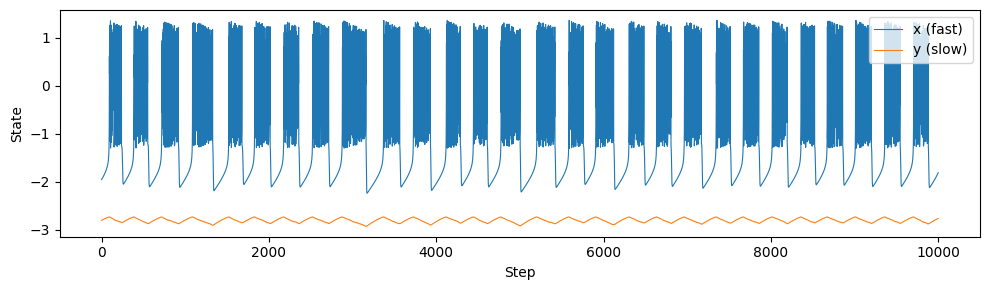

Chosen ridge alpha: 10.0

One-step metrics:
NRMSE x: 0.6668260789
NRMSE y: 0.1416080999

Closed-loop metrics:
NRMSE x: 1.0905337396
NRMSE y: 1.3092464645


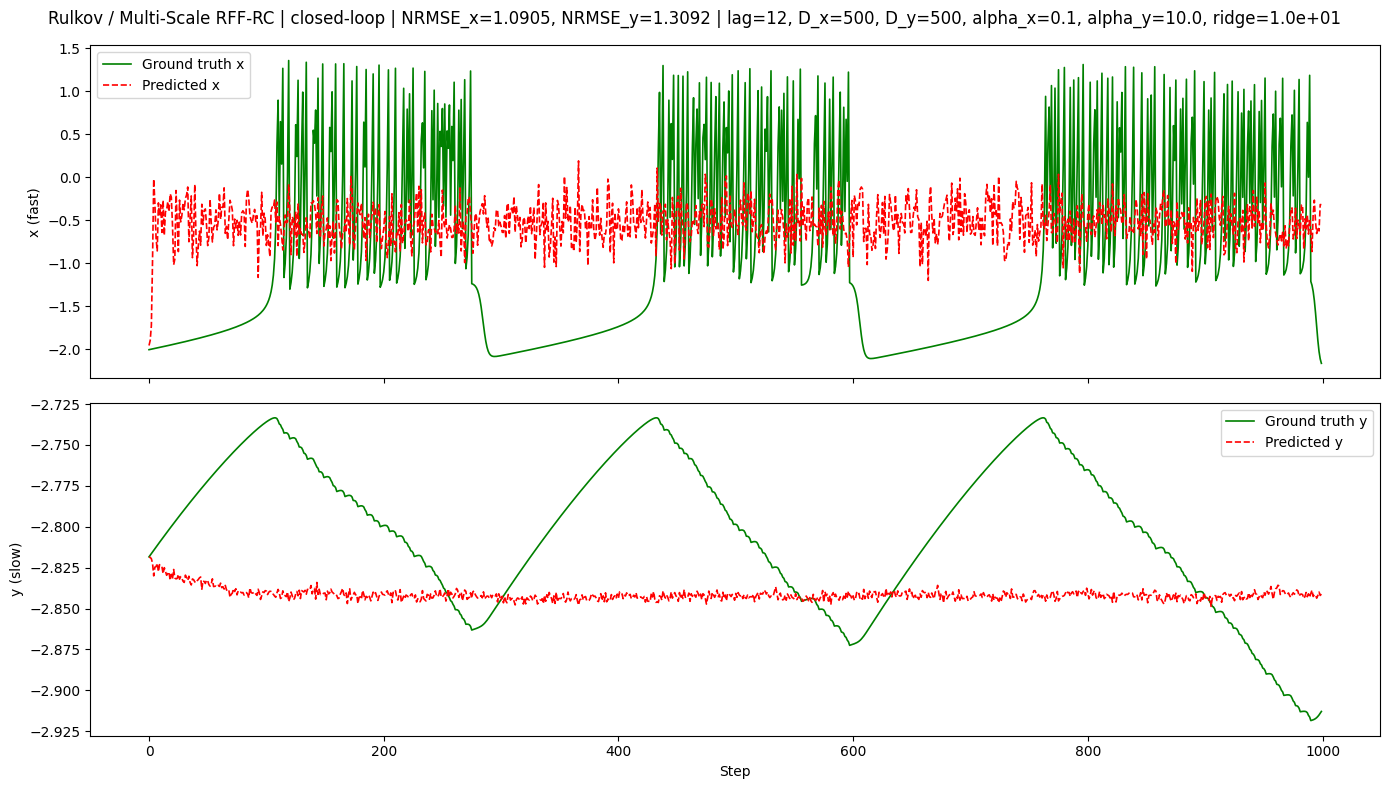

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_squared_error

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../..',)))
from lib.utils.reservoirpy import (
    fit_scaler, transform_array, inverse_transform_array
)

np.random.seed(42)

# ==========================================================
# LOAD DATA
# ==========================================================
# IMPORTANT:
# For the paper-faithful Rulkov implementation, dataset should contain BOTH
# variables, e.g. columns [x, y].
#
# If your file currently has only one column, this code will still work in a
# single-observable mode, but that is not the exact methodology of the paper.
dataset = np.loadtxt('../../../data/chaotic_data/rulkov_map.csv', delimiter=',')

if dataset.ndim == 1:
    dataset = dataset.reshape(-1, 1)

# Optional: if file has more than 2 columns, keep first two
if dataset.shape[1] >= 2:
    dataset = dataset[:, :2]

fig, ax = plt.subplots(figsize=(10, 3))
if dataset.shape[1] == 1:
    ax.plot(dataset[:, 0], color='steelblue', linewidth=0.8)
    ax.set_ylabel('Signal')
else:
    ax.plot(dataset[:, 0], linewidth=0.8, label='x (fast)')
    ax.plot(dataset[:, 1], linewidth=0.8, label='y (slow)')
    ax.legend()
    ax.set_ylabel('State')
ax.set_xlabel('Step')
plt.tight_layout()
plt.show()


# ==========================================================
# FIXED SETTINGS
# ==========================================================
train_len  = 4000
test_start = 4000
test_len   = 1000
seed       = 42

# Delay embedding length per variable
lag = 12

# Number of random Fourier features per variable block
D_x = 500
D_y = 500

# Paper-inspired multi-scale bandwidths for Rulkov
# fast x: narrower bandwidth
# slow y: broader bandwidth
alpha_x = 0.1
alpha_y = 10.0

# For single-observable fallback mode
alpha_single = 0.1

# Ridge grid
ridge_alphas = np.logspace(-8, 2, 11)

# Scaling
normalization = "minmax11"


# ==========================================================
# HELPERS
# ==========================================================
def build_delay_embedding_multivar(data, lag):
    """
    data: shape (T, n_vars)
    Returns:
        X: shape (T-lag, lag*n_vars)
        Y: shape (T-lag, n_vars)
    Delay layout:
        [x_t, x_{t-1}, ..., x_{t-lag+1}, y_t, y_{t-1}, ..., y_{t-lag+1}, ...]
    """
    T, n_vars = data.shape
    X, Y = [], []
    for t in range(lag, T):
        blocks = []
        for j in range(n_vars):
            block = data[t-lag:t, j][::-1]   # most recent first
            blocks.append(block)
        X.append(np.concatenate(blocks))
        Y.append(data[t])
    return np.asarray(X), np.asarray(Y)


def rff_map(X, W, b):
    """
    Random Fourier Features:
    z(x) = sqrt(2/D) * cos(XW + b)
    X: (N, d)
    W: (d, D)
    b: (D,)
    """
    D = W.shape[1]
    return np.sqrt(2.0 / D) * np.cos(X @ W + b)


class MultiScaleRFFReservoir:
    """
    Paper-faithful reservoir:
    - delay embedding
    - variable-wise RFF blocks
    - concatenation
    """
    def __init__(self, lag, n_vars, D_per_var, alphas, rng_seed=42):
        self.lag = lag
        self.n_vars = n_vars
        self.D_per_var = D_per_var
        self.alphas = alphas
        self.rng = np.random.RandomState(rng_seed)

        self.W_blocks = []
        self.b_blocks = []

        for j in range(n_vars):
            D = D_per_var[j]
            alpha = alphas[j]

            # For Gaussian kernel, frequencies are sampled from N(0, 1/alpha^2)
            W = self.rng.normal(
                loc=0.0,
                scale=1.0 / alpha,
                size=(lag, D)
            )
            b = self.rng.uniform(0.0, 2.0 * np.pi, size=D)

            self.W_blocks.append(W)
            self.b_blocks.append(b)

    def transform(self, X_delay):
        """
        X_delay shape: (N, lag*n_vars)
        returns concatenated RFF features
        """
        feats = []
        for j in range(self.n_vars):
            start = j * self.lag
            end   = (j + 1) * self.lag
            Xj = X_delay[:, start:end]
            Zj = rff_map(Xj, self.W_blocks[j], self.b_blocks[j])
            feats.append(Zj)
        return np.hstack(feats)


class SingleScaleRFFReservoir:
    """
    Single-scale comparator:
    one global bandwidth on the full delay vector
    """
    def __init__(self, input_dim, D_total, alpha, rng_seed=42):
        self.rng = np.random.RandomState(rng_seed)
        self.W = self.rng.normal(
            loc=0.0,
            scale=1.0 / alpha,
            size=(input_dim, D_total)
        )
        self.b = self.rng.uniform(0.0, 2.0 * np.pi, size=D_total)

    def transform(self, X_delay):
        return rff_map(X_delay, self.W, self.b)


def nrmse(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))
    denom = np.std(y_true, axis=0)
    denom = np.where(denom == 0, 1.0, denom)
    return rmse / denom


def update_delay_vector(delay_vec, pred, n_vars, lag):
    """
    delay_vec layout:
    [x_t, x_{t-1}, ..., x_{t-lag+1}, y_t, y_{t-1}, ..., y_{t-lag+1}, ...]
    pred shape: (n_vars,)
    """
    next_delay = delay_vec.copy()
    for j in range(n_vars):
        start = j * lag
        end   = (j + 1) * lag
        block = next_delay[start:end]
        block[1:] = block[:-1]
        block[0]  = pred[j]
        next_delay[start:end] = block
    return next_delay


# ==========================================================
# DATA PREPARATION
# ==========================================================
X_raw, Y_raw = build_delay_embedding_multivar(dataset, lag)

# Shift train/test because of delay construction
X_train_raw = X_raw[:train_len]
Y_train_raw = Y_raw[:train_len]
X_test_raw  = X_raw[test_start:test_start + test_len]
Y_test_raw  = Y_raw[test_start:test_start + test_len]

n_vars = Y_raw.shape[1]

# Scale delays and targets
x_scaler = fit_scaler(X_train_raw, method=normalization)
y_scaler = fit_scaler(Y_train_raw, method=normalization)

X_train = transform_array(X_train_raw, x_scaler)
Y_train = transform_array(Y_train_raw, y_scaler)
X_test  = transform_array(X_test_raw,  x_scaler)
Y_test  = transform_array(Y_test_raw,  y_scaler)


# ==========================================================
# BUILD PAPER-FAITHFUL MULTI-SCALE RFF RESERVOIR
# ==========================================================
if n_vars == 1:
    print("WARNING: only one observable found. This is not the full two-variable Rulkov setup.")
    ms_reservoir = SingleScaleRFFReservoir(
        input_dim=lag,
        D_total=1000,
        alpha=alpha_single,
        rng_seed=seed
    )
    F_train = ms_reservoir.transform(X_train)
    F_test  = ms_reservoir.transform(X_test)
else:
    ms_reservoir = MultiScaleRFFReservoir(
        lag=lag,
        n_vars=n_vars,
        D_per_var=[D_x, D_y],
        alphas=[alpha_x, alpha_y],
        rng_seed=seed
    )
    F_train = ms_reservoir.transform(X_train)
    F_test  = ms_reservoir.transform(X_test)

# Cross-validated ridge
readout = RidgeCV(alphas=ridge_alphas)
readout.fit(F_train, Y_train)

print(f"Chosen ridge alpha: {readout.alpha_}")


# ==========================================================
# ONE-STEP PREDICTION
# ==========================================================
Y_pred_1_scaled = readout.predict(F_test)

Y_pred_1 = inverse_transform_array(Y_pred_1_scaled, y_scaler)
Y_true_1 = inverse_transform_array(Y_test, y_scaler)

nrmse_1 = nrmse(Y_true_1, Y_pred_1)

print("\nOne-step metrics:")
if n_vars == 1:
    print(f"NRMSE: {nrmse_1[0]:.10f}")
else:
    print(f"NRMSE x: {nrmse_1[0]:.10f}")
    print(f"NRMSE y: {nrmse_1[1]:.10f}")


# ==========================================================
# CLOSED-LOOP MULTI-STEP FORECAST
# ==========================================================
pred_len = test_len
current_delay = X_test[0].copy()
Y_pred_cl_scaled = np.zeros((pred_len, n_vars))

for k in range(pred_len):
    feat = ms_reservoir.transform(current_delay.reshape(1, -1))
    pred = readout.predict(feat)[0]
    Y_pred_cl_scaled[k] = pred
    current_delay = update_delay_vector(current_delay, pred, n_vars, lag)

Y_pred_cl = inverse_transform_array(Y_pred_cl_scaled, y_scaler)
Y_true_cl = inverse_transform_array(Y_test[:pred_len], y_scaler)

nrmse_cl = nrmse(Y_true_cl, Y_pred_cl)

print("\nClosed-loop metrics:")
if n_vars == 1:
    print(f"NRMSE: {nrmse_cl[0]:.10f}")
else:
    print(f"NRMSE x: {nrmse_cl[0]:.10f}")
    print(f"NRMSE y: {nrmse_cl[1]:.10f}")


# ==========================================================
# PLOTTING (same general style as yours)
# ==========================================================
if n_vars == 1:
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(np.arange(pred_len), Y_true_cl[:, 0], c="green",
            label="Ground truth", linewidth=1.2)
    ax.plot(np.arange(pred_len), Y_pred_cl[:, 0], ls="--", c="red",
            label="Multi-scale RFF closed-loop prediction", lw=1.2)
    ax.set_title(
        f"Rulkov / Multi-Scale RFF-RC | closed-loop | "
        f"NRMSE={nrmse_cl[0]:.4f} | lag={lag}, D={1000}, alpha={alpha_single}, ridge={readout.alpha_:.1e}"
    )
    ax.set_xlabel("Step")
    ax.set_ylabel("Signal")
    ax.legend()
    plt.tight_layout()
    plt.show()

else:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    axes[0].plot(np.arange(pred_len), Y_true_cl[:, 0], c="green",
                 label="Ground truth x", linewidth=1.2)
    axes[0].plot(np.arange(pred_len), Y_pred_cl[:, 0], ls="--", c="red",
                 label="Predicted x", lw=1.2)
    axes[0].set_ylabel("x (fast)")
    axes[0].legend()

    axes[1].plot(np.arange(pred_len), Y_true_cl[:, 1], c="green",
                 label="Ground truth y", linewidth=1.2)
    axes[1].plot(np.arange(pred_len), Y_pred_cl[:, 1], ls="--", c="red",
                 label="Predicted y", lw=1.2)
    axes[1].set_ylabel("y (slow)")
    axes[1].set_xlabel("Step")
    axes[1].legend()

    fig.suptitle(
        f"Rulkov / Multi-Scale RFF-RC | closed-loop | "
        f"NRMSE_x={nrmse_cl[0]:.4f}, NRMSE_y={nrmse_cl[1]:.4f} | "
        f"lag={lag}, D_x={D_x}, D_y={D_y}, alpha_x={alpha_x}, alpha_y={alpha_y}, ridge={readout.alpha_:.1e}"
    )
    plt.tight_layout()
    plt.show()